# RGBFreqNet: RGB-якорь + SRM + FFT Phase

### Архитектура RGBFreqNet:
```
Image [B, 3, 256, 256]
         │
    ┌────┼──────────────┐
    │    │              │
 RGB    SRM          Phase
 (якорь) (шум)     (фаза FFT)
    │    │              │
 ResNet  CNN          CNN
  512    128          128
    │    │              │
    └────┴──────────────┘
          cat [768]
          BN → Linear(256) → SiLU → Dropout → Linear(1)
```

### Почему это работает:
- RGB backbone (~5M params) — надёжный якорь, сразу даёт F1 > 0.85
- SRM поток — 128 features, лёгкий, не доминирует
- Phase поток — cos+sin, лёгкий, 128 features
- Все потоки обучаются на одной задаче, RGB тащит их за собой


In [ ]:
!pip install -q scikit-learn tqdm

In [ ]:
!pip install -q --upgrade albumentations

In [ ]:
import math, os, random, warnings, json
from copy import deepcopy
from pathlib import Path

import albumentations as A
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from torch.cuda.amp import GradScaler, autocast
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Torch:', torch.__version__)
print('Device:', DEVICE)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Torch: 2.10.0+cu128
Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


In [ ]:
CFG = dict(
    seed           = 42,
    val_size       = 0.20,
    image_size     = 256,

    epochs         = 25,
    batch_size     = 32,
    num_workers    = 2,
    amp            = True,
    grad_clip      = 1.0,
    early_stop     = 7,

    lr             = 2e-4,
    weight_decay   = 1e-4,
    warmup_epochs  = 2,
    min_lr_ratio   = 0.05,

    ema_decay      = 0.9995,

    # ОДИН механизм балансировки: pos_weight
    use_pos_weight  = True,
    label_smoothing = 0.05,

    mixup_alpha    = 0.0,
    mixup_prob     = 0.0,

    sbi_enabled    = False,
    sbi_prob_start = 0.10,
    sbi_prob_end   = 0.35,
    sbi_sched_start= 3,
    sbi_sched_end  = 12,

    # Аугментации — умеренные, не убиваем GAN артефакты
    aug_compression_prob     = 0.00,
    aug_resize_artifact_prob = 0.00,
    aug_blur_prob            = 0.00,
    aug_noise_prob           = 0.00,
    aug_color_prob           = 0.00,
    aug_dropout_prob         = 0.05,

    tta_hflip      = True,

    # Архитектура
    rgb_base_ch    = 64,   # базовые каналы RGB backbone
    freq_ch        = 128,  # размер каждого частотного потока
    hpf_scale      = 4,    # high-pass: зануляем центр 1/4
    dropout        = 0.3,
)

BASE_PATH      = '/content/dataset_root/dataset'
TRAIN_IMG_PATH = os.path.join(BASE_PATH, 'train_images')
TEST_IMG_PATH  = os.path.join(BASE_PATH, 'test_images')
SOLUTION_PATH  = os.path.join(BASE_PATH, 'train_solution.csv')
OUTPUT_DIR     = Path('/content/rgbfreq')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print('Output dir:', OUTPUT_DIR)

Output dir: /content/rgbfreq


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
zip_path = '/content/drive/MyDrive/FFT/ml-intensive-yandex-academy-spring-2026.zip'
!unzip -q "{zip_path}" -d "/content/dataset_root"
print('Unzipped.')

Mounted at /content/drive
Unzipped.


In [ ]:
def set_seed(s):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)

set_seed(CFG['seed'])

full_df = pd.read_csv(SOLUTION_PATH, header=None)
full_df.columns = ['Id', 'target_feature']
full_df['Id'] = full_df['Id'].astype(str)
print('Total:', len(full_df))
print(full_df['target_feature'].value_counts())

train_df, holdout_df = train_test_split(
    full_df, test_size=CFG['val_size'],
    random_state=CFG['seed'], stratify=full_df['target_feature'])
train_df   = train_df.reset_index(drop=True)
holdout_df = holdout_df.reset_index(drop=True)
print(f'Train: {len(train_df)}  Holdout: {len(holdout_df)}')

Total: 50000
target_feature
0    41500
1     8500
Name: count, dtype: int64
Train: 40000  Holdout: 10000


## Dataset

In [ ]:
IMAGE_EXTS = {'.jpg','.jpeg','.png','.bmp','.webp'}

def build_stem_map(d):
    d = Path(d)
    m = {p.stem: p for p in d.iterdir()
         if p.suffix.lower() in IMAGE_EXTS and p.is_file()}
    if not m: raise FileNotFoundError(d)
    return m


class FaceDataset(Dataset):
    def __init__(self, df, images_dir, transform, with_target=True,
                 sbi_enabled=False, sbi_prob=0.):
        self.df=df.reset_index(drop=True); self.tf=transform
        self.with_target=with_target
        self.stem_map=build_stem_map(images_dir)
        self.sbi_enabled=sbi_enabled; self.sbi_prob=float(sbi_prob)

    def set_sbi_prob(self, p): self.sbi_prob=max(0.,min(1.,float(p)))
    def __len__(self): return len(self.df)

    def _read(self, path):
        img=cv2.imread(str(path),cv2.IMREAD_COLOR)
        if img is None: raise FileNotFoundError(path)
        return cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    def _sbi(self, img):
        h,w=img.shape[:2]
        if h<32 or w<32: return img
        pw=max(20,min(w-2,int(np.random.uniform(0.28,0.55)*w)))
        ph=max(20,min(h-2,int(np.random.uniform(0.28,0.55)*h)))
        x1=np.random.randint(0,w-pw+1); y1=np.random.randint(0,h-ph+1)
        src=img[y1:y1+ph,x1:x1+pw].copy()
        if np.random.rand()<0.5: src=cv2.flip(src,1)
        if np.random.rand()<0.7:
            ds=np.random.uniform(0.45,0.8)
            dh,dw=max(8,int(ph*ds)),max(8,int(pw*ds))
            src=cv2.resize(cv2.resize(src,(dw,dh),cv2.INTER_AREA),(pw,ph),cv2.INTER_LINEAR)
        if np.random.rand()<0.6:
            src=cv2.GaussianBlur(src,(3,3),float(np.random.uniform(0.2,1.2)))
        src=np.clip(src.astype(np.float32)*np.random.uniform(0.86,1.14)
                    +np.random.uniform(-14.,14.),0,255).astype(np.uint8)
        mask=np.zeros((ph,pw),np.float32)
        cx=np.random.randint(pw//3,max(pw//3+1,pw-pw//3))
        cy=np.random.randint(ph//3,max(ph//3+1,ph-ph//3))
        cv2.ellipse(mask,(cx,cy),
                    (max(6,int(pw*np.random.uniform(0.25,0.55))),
                     max(6,int(ph*np.random.uniform(0.25,0.55)))),
                    float(np.random.uniform(0,180)),0,360,1.,-1)
        bk=int(np.random.choice([5,7,9,11]))
        mask=np.clip(cv2.GaussianBlur(mask,(bk,bk),0)*np.random.uniform(0.6,0.9),0.,1.)[...,None]
        out=img.copy()
        out[y1:y1+ph,x1:x1+pw]=np.clip(
            mask*src.astype(np.float32)+(1-mask)*img[y1:y1+ph,x1:x1+pw].astype(np.float32),
            0,255).astype(np.uint8)
        return out

    def __getitem__(self, idx):
        row=self.df.iloc[idx]
        img=self._read(self.stem_map[str(row['Id'])])
        if not self.with_target:
            img=self.tf(image=img)['image']
            return torch.from_numpy(img.transpose(2,0,1).astype(np.float32)),row['Id']
        tval=float(row['target_feature'])
        if self.sbi_enabled and np.isclose(tval,0.) and np.random.rand()<self.sbi_prob:
            img=self._sbi(img); tval=1.
        img=self.tf(image=img)['image']
        return (torch.from_numpy(img.transpose(2,0,1).astype(np.float32)),
                torch.tensor(tval,dtype=torch.float32))


def build_train_tf(sz):
    ds=max(8,int(sz*0.05)); dl=max(12,int(sz*0.18))
    return A.Compose([
        A.RandomResizedCrop(size=(sz,sz),scale=(0.8,1.0),p=1.),
        A.HorizontalFlip(p=0.5),
        # Умеренное сжатие (слишком сильное убивает GAN артефакты)
        A.OneOf([A.ImageCompression(quality_lower=40, quality_upper=85,p=1.)],
                p=CFG['aug_compression_prob']),
        A.OneOf([A.Downscale(
                    scale_range=(0.45,0.80),
                    interpolation_pair={'downscale':cv2.INTER_AREA,'upscale':cv2.INTER_LINEAR},
                    p=1.)], p=CFG['aug_resize_artifact_prob']),
        A.OneOf([A.GaussianBlur(blur_limit=(3,5),p=1.),
                 A.MotionBlur(blur_limit=5,p=1.)], p=CFG['aug_blur_prob']),
        A.OneOf([A.GaussNoise(std_range=(0.,0.03),p=1.),
                 A.ISONoise(color_shift=(0.01,0.04),intensity=(0.1,0.3),p=1.)],
                p=CFG['aug_noise_prob']),
        A.OneOf([A.RandomBrightnessContrast(0.15,0.15,p=1.),
                 A.HueSaturationValue(6,10,8,p=1.)], p=CFG['aug_color_prob']),
        A.CoarseDropout(num_holes_range=(1,2),
                        hole_height_range=(ds,dl),hole_width_range=(ds,dl),
                        fill=0,p=CFG['aug_dropout_prob']),
        A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ])

def build_valid_tf(sz):
    return A.Compose([
        A.Resize(sz,sz),
        A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ])

def get_pos_weight(targets):
    arr=np.asarray(targets).astype(int)
    pos,neg=(arr==1).sum(),(arr==0).sum()
    return 3.5 if pos>0 else 1.

print('Dataset ready.')

Dataset ready.


## Диагностика входных данных

Перед обучением убеждаемся что все три потока получают разумные значения.

In [ ]:
diag_ds = FaceDataset(
    train_df.head(64), TRAIN_IMG_PATH,
    build_valid_tf(CFG['image_size']))
diag_loader = DataLoader(diag_ds, batch_size=8, shuffle=False)

imgs, tgts = next(iter(diag_loader))
print(f'Input tensor: shape={imgs.shape}')
print(f'  range:  [{imgs.min():.3f}, {imgs.max():.3f}]')
print(f'  mean:   {imgs.mean():.4f}  (должно быть близко к 0)')
print(f'  std:    {imgs.std():.4f}   (должно быть ~1)')

# Проверим SRM выход
def _make_srm_kernels():
    k1=np.array([[0,0,0,0,0],[0,-1,2,-1,0],[0,2,-4,2,0],[0,-1,2,-1,0],[0,0,0,0,0]],np.float32)/4.
    k2=np.array([[-1,2,-2,2,-1],[2,-6,8,-6,2],[-2,8,-12,8,-2],[2,-6,8,-6,2],[-1,2,-2,2,-1]],np.float32)/12.
    k3=np.array([[0,0,0,0,0],[0,0,0,0,0],[0,1,-2,1,0],[0,0,0,0,0],[0,0,0,0,0]],np.float32)/2.
    return np.stack([k1,k2,k3],axis=0)

srm_conv = nn.Conv2d(3,9,5,padding=2,bias=False,groups=3)
k=_make_srm_kernels(); w=np.zeros((9,1,5,5),np.float32)
for c in range(3):
    for i in range(3): w[c*3+i,0]=k[i]
with torch.no_grad(): srm_conv.weight.copy_(torch.from_numpy(w))

with torch.no_grad():
    srm_out = srm_conv(imgs)
    print(f'\nSRM output: shape={srm_out.shape}')
    print(f'  range: [{srm_out.min():.4f}, {srm_out.max():.4f}]')
    print(f'  std:   {srm_out.std():.4f}  (должно быть заметно > 0)')

# Проверим Phase stream
with torch.no_grad():
    xf = torch.fft.fft2(imgs, norm='ortho')
    xf_s = torch.fft.fftshift(xf, dim=[-2,-1])
    b,c,h,w = xf_s.shape; s=4
    mask = torch.ones(1,1,h,w)
    mask[:,:,h//2-h//s:h//2+h//s,w//2-w//s:w//2+w//s]=0.
    xf_hp = xf_s * mask
    phase = torch.angle(xf_hp)
    cos_p = torch.cos(phase); sin_p = torch.sin(phase)
    phase_in = torch.cat([cos_p, sin_p], dim=1)
    print(f'\nPhase stream (cos+sin): shape={phase_in.shape}')
    print(f'  range: [{phase_in.min():.4f}, {phase_in.max():.4f}]  (должно быть [-1,1])')
    print(f'  std:   {phase_in.std():.4f}')

print('\n✓ Все потоки имеют разумные значения!')
del diag_ds, diag_loader

Input tensor: shape=torch.Size([8, 3, 256, 256])
  range:  [-2.118, 2.640]
  mean:   -0.0882  (должно быть близко к 0)
  std:    1.2229   (должно быть ~1)

SRM output: shape=torch.Size([8, 9, 256, 256])
  range: [-7.9438, 7.9526]
  std:   0.7642  (должно быть заметно > 0)

Phase stream (cos+sin): shape=torch.Size([8, 6, 256, 256])
  range: [-1.0000, 1.0000]  (должно быть [-1,1])
  std:   0.7044

✓ Все потоки имеют разумные значения!


## Архитектура RGBFreqNet

RGB backbone теперь доминирует (512 признаков),
частотные потоки — вспомогательные (по 128 признаков каждый).
- SRM шумовые остатки (ловит GAN upsampling noise)
- FFT Phase cos+sin (ловит периодические паттерны StyleGAN)


In [ ]:
class SEBlock(nn.Module):
    def __init__(self, ch, r=8):
        super().__init__()
        h=max(ch//r,8)
        self.pool=nn.AdaptiveAvgPool2d(1)
        self.fc=nn.Sequential(
            nn.Conv2d(ch,h,1,bias=True),nn.SiLU(True),
            nn.Conv2d(h,ch,1,bias=True),nn.Sigmoid())
    def forward(self,x): return x*self.fc(self.pool(x))


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, use_se=True):
        super().__init__()
        self.c1=nn.Sequential(
            nn.Conv2d(in_ch,out_ch,3,stride=stride,padding=1,bias=False),
            nn.BatchNorm2d(out_ch),nn.SiLU(True))
        self.c2=nn.Sequential(
            nn.Conv2d(out_ch,out_ch,3,padding=1,bias=False),
            nn.BatchNorm2d(out_ch))
        self.se=SEBlock(out_ch) if use_se else nn.Identity()
        self.act=nn.SiLU(True)
        self.skip=(
            nn.Sequential(
                nn.Conv2d(in_ch,out_ch,1,stride=stride,bias=False),
                nn.BatchNorm2d(out_ch))
            if (stride!=1 or in_ch!=out_ch) else nn.Identity())
    def forward(self,x):
        return self.act(self.se(self.c2(self.c1(x)))+self.skip(x))


class FixedSRMConv(nn.Module):
    """SRM фильтры: 3 RGB → 9 шумовых остатков (заморожены)"""
    def __init__(self):
        super().__init__()
        self.conv=nn.Conv2d(3,9,5,padding=2,bias=False,groups=3)
        k1=np.array([[0,0,0,0,0],[0,-1,2,-1,0],[0,2,-4,2,0],[0,-1,2,-1,0],[0,0,0,0,0]],np.float32)/4.
        k2=np.array([[-1,2,-2,2,-1],[2,-6,8,-6,2],[-2,8,-12,8,-2],[2,-6,8,-6,2],[-1,2,-2,2,-1]],np.float32)/12.
        k3=np.array([[0,0,0,0,0],[0,0,0,0,0],[0,1,-2,1,0],[0,0,0,0,0],[0,0,0,0,0]],np.float32)/2.
        kk=np.stack([k1,k2,k3],axis=0)
        w=np.zeros((9,1,5,5),np.float32)
        for c in range(3):
            for i in range(3): w[c*3+i,0]=kk[i]
        with torch.no_grad(): self.conv.weight.copy_(torch.from_numpy(w))
        self.conv.weight.requires_grad_(False)
    def forward(self,x): return self.conv(x)


def extract_phase_cos_sin(x: torch.Tensor, hpf_scale: int = 4) -> torch.Tensor:
    """
    FFT Phase как cos(φ) + sin(φ) после high-pass фильтра.

    cos/sin непрерывны и однозначно кодируют угол.

    Выход: [B, 6, H, W] (cos и sin для каждого из 3 каналов)
    """
    xf = torch.fft.fft2(x, norm='ortho')
    xf = torch.fft.fftshift(xf, dim=[-2,-1])

    b, c, h, w = xf.shape
    s = hpf_scale
    mask = torch.ones(1, 1, h, w, dtype=x.dtype, device=x.device)
    mask[:, :, h//2-h//s : h//2+h//s, w//2-w//s : w//2+w//s] = 0.
    xf = xf * mask

    phase = torch.angle(xf)     # [B, 3, H, W], ∈ [-π, π]
    cos_p = torch.cos(phase)    # [B, 3, H, W], ∈ [-1, 1]
    sin_p = torch.sin(phase)    # [B, 3, H, W], ∈ [-1, 1]

    return torch.cat([cos_p, sin_p], dim=1)   # [B, 6, H, W]


class RGBFreqNet(nn.Module):
    """
    RGB backbone + SRM поток + FFT Phase поток.

    Распределение мощности:
      RGB   → 512 features
      SRM   → 128 features
      Phase → 128 features
      ──────────────────────
      Fusion: 768 → 256 → 1
    """

    def __init__(self, rgb_base_ch=64, freq_ch=128, hpf_scale=4, dropout=0.3):
        super().__init__()
        self.hpf_scale = hpf_scale
        B = rgb_base_ch

        # ────────────────────────────────────────────
        # Поток 1: RGB backbone
        # ResNet-style: 3→64→128→256→512
        # ────────────────────────────────────────────
        self.rgb_stem = nn.Sequential(
            nn.Conv2d(3, B, 7, stride=2, padding=3, bias=False),  # 256→128
            nn.BatchNorm2d(B), nn.SiLU(True),
            nn.MaxPool2d(3, stride=2, padding=1),                  # 128→64
        )
        self.rgb_layer1 = nn.Sequential(
            ResBlock(B,   B*2, stride=2),    # 64→32
            ResBlock(B*2, B*2),
        )
        self.rgb_layer2 = nn.Sequential(
            ResBlock(B*2, B*4, stride=2),    # 32→16
            ResBlock(B*4, B*4),
        )
        self.rgb_layer3 = nn.Sequential(
            ResBlock(B*4, B*8, stride=2),    # 16→8
            ResBlock(B*8, B*8),
        )
        self.rgb_pool = nn.AdaptiveAvgPool2d(1)
        # output: [B, B*8 = 512]

        # ────────────────────────────────────────────
        # Поток 2: SRM
        # ────────────────────────────────────────────
        F = freq_ch
        self.srm_conv = FixedSRMConv()  # 3→9, заморожен
        self.srm_net  = nn.Sequential(
            nn.Conv2d(9, F//2, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(F//2), nn.SiLU(True),
            ResBlock(F//2, F,    stride=2, use_se=False),
            ResBlock(F,    F,    stride=2, use_se=False),
            ResBlock(F,    F*2,  stride=2, use_se=False),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
        )

        self.srm_proj = nn.Linear(F*2, F)
        # output SRM: [B, F = 128]
        # ────────────────────────────────────────────
        # Поток 3: FFT Phase cos+sin
        # ────────────────────────────────────────────
        # Вход: 6 каналов (cos+sin для 3 RGB)
        self.phase_net = nn.Sequential(
            nn.Conv2d(6, F//2, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(F//2), nn.SiLU(True),
            ResBlock(F//2, F,    stride=2, use_se=False),
            ResBlock(F,    F,    stride=2, use_se=False),
            ResBlock(F,    F*2,  stride=2, use_se=False),
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
        )  # output: [B, F*2]
        self.phase_proj = nn.Linear(F*2, F)
        # output Phase: [B, F = 128]

        # ────────────────────────────────────────────
        # Fusion: cat[512+128+128=768] → голова
        # ────────────────────────────────────────────
        fused_dim = B*8 + F + F   # 512 + 128 + 128 = 768
        self.head = nn.Sequential(
            nn.BatchNorm1d(fused_dim),
            nn.Dropout(dropout),
            nn.Linear(fused_dim, 256),
            nn.SiLU(True),
            nn.Dropout(dropout * 0.5),
            nn.Linear(256, 1),
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d) and m.weight.requires_grad:
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ── Поток 1: RGB
        r = self.rgb_stem(x)
        r = self.rgb_layer1(r)
        r = self.rgb_layer2(r)
        r = self.rgb_layer3(r)
        f_rgb = self.rgb_pool(r).flatten(1)            # [B, 512]

        # ── Поток 2: SRM (без градиентов через замороженные ядра)
        with torch.no_grad():
            srm_in = self.srm_conv(x)                  # [B, 9, H, W]
        f_srm = self.srm_proj(self.srm_net(srm_in))    # [B, 128]

        # ── Поток 3: FFT Phase
        phase_in = extract_phase_cos_sin(x, self.hpf_scale)  # [B, 6, H, W]
        f_phase  = self.phase_proj(self.phase_net(phase_in))  # [B, 128]

        # ── Fusion
        fused = torch.cat([f_rgb, f_srm, f_phase], dim=1)    # [B, 768]
        return self.head(fused)                                # [B, 1]


# Проверка
set_seed(0)
_m = RGBFreqNet(
    rgb_base_ch = CFG['rgb_base_ch'],
    freq_ch     = CFG['freq_ch'],
    hpf_scale   = CFG['hpf_scale'],
    dropout     = CFG['dropout'],
).to(DEVICE)

_x = torch.randn(2, 3, 256, 256, device=DEVICE)
_y = _m(_x)
print(f'Output: {_y.shape}  ← ожидается [2, 1]')

total  = sum(p.numel() for p in _m.parameters())
train  = sum(p.numel() for p in _m.parameters() if p.requires_grad)
frozen = total - train
print(f'Total:    {total:,}')
print(f'Trainable:{train:,}')
print(f'Frozen:   {frozen:,}  (SRM kernels)')

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
    _ = _m(torch.randn(32,3,256,256,device=DEVICE))
    mem = torch.cuda.max_memory_allocated()/1e6
    print(f'\nGPU при batch=32: {mem:.0f} MB  (из 15000 MB)')

del _m, _x, _y

Output: torch.Size([2, 1])  ← ожидается [2, 1]
Total:    14,398,658
Trainable:14,398,433
Frozen:   225  (SRM kernels)

GPU при batch=32: 3475 MB  (из 15000 MB)


## Утилиты обучения

In [ ]:
class ModelEMA:
    def __init__(self, model, decay=0.9995):
        self.decay = decay
        self.model = deepcopy(model).eval()
        for p in self.model.parameters(): p.requires_grad_(False)
    @torch.no_grad()
    def update(self, model):
        for k, v in self.model.state_dict().items():
            mv = model.state_dict()[k]
            if v.dtype.is_floating_point:
                v.mul_(self.decay).add_(mv, alpha=1-self.decay)
            else: v.copy_(mv)


def build_cosine_scheduler(optimizer, epochs, steps_per_epoch,
                            warmup_epochs=1.5, min_lr_ratio=0.05):
    total  = max(epochs * steps_per_epoch, 1)
    warmup = int(warmup_epochs * steps_per_epoch)
    def fn(step):
        if warmup > 0 and step < warmup:
            return (step+1) / max(warmup,1)
        p   = (step-warmup) / max(total-warmup,1)
        cos = 0.5*(1+math.cos(math.pi*min(max(p,0.),1.)))
        return min_lr_ratio + (1-min_lr_ratio)*cos
    return LambdaLR(optimizer, fn)


def apply_mixup(imgs, tgts, alpha, prob):
    if alpha <= 0 or np.random.rand() > prob: return imgs, tgts
    lam = float(np.random.beta(alpha, alpha))
    idx = torch.randperm(imgs.size(0), device=imgs.device)
    return lam*imgs+(1-lam)*imgs[idx], lam*tgts+(1-lam)*tgts[idx]


def find_best_threshold(probs, y_true, n=401):
    best={'thr':0.5,'f1':-1.,'p':0.,'r':0.}
    for thr in np.linspace(0.20, 0.95, n):
        pred=(probs>=thr).astype(int)
        f1=f1_score(y_true,pred,zero_division=0)
        if f1>best['f1']:
            best={'thr':float(thr),'f1':float(f1),
                  'p':float(precision_score(y_true,pred,zero_division=0)),
                  'r':float(recall_score(y_true,pred,zero_division=0))}
    return best


@torch.no_grad()
def collect_logits(model, loader, device):
    model.eval()
    lg, tg = [], []
    for imgs, targets in loader:
        lg.append(model(imgs.to(device,non_blocking=True)).squeeze(1).cpu().numpy())
        tg.append(targets.numpy())
    return np.concatenate(lg), np.concatenate(tg).astype(int)


def train_one_epoch(model, loader, optimizer, scheduler, scaler,
                    device, ema, pos_weight, label_smoothing):
    model.train()
    total_loss = 0.
    pbar = tqdm(loader, desc='  Train', leave=False)
    for imgs, tgts in pbar:
        imgs = imgs.to(device, non_blocking=True)
        tgts = tgts.to(device, non_blocking=True)
        imgs, tgts = apply_mixup(imgs, tgts, CFG['mixup_alpha'], CFG['mixup_prob'])
        if label_smoothing > 0:
            tgts = tgts*(1-label_smoothing) + 0.5*label_smoothing
        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=CFG['amp'] and device.type=='cuda'):
            logits = model(imgs).squeeze(1)
            loss   = F.binary_cross_entropy_with_logits(
                logits, tgts, pos_weight=pos_weight)
        scaler.scale(loss).backward()
        if CFG['grad_clip'] > 0:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), CFG['grad_clip'])
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        ema.update(model)
        total_loss += loss.item()*imgs.size(0)
        pbar.set_postfix(loss=f'{loss.item():.4f}')
    return total_loss / len(loader.dataset)


print('Training utilities ready.')

Training utilities ready.


## Обучение

In [ ]:
set_seed(CFG['seed'])

pw_val    = get_pos_weight(train_df['target_feature'].values)
pw_tensor = torch.tensor([pw_val], device=DEVICE, dtype=torch.float32)

train_ds = FaceDataset(
    train_df, TRAIN_IMG_PATH, build_train_tf(CFG['image_size']),
    with_target=True, sbi_enabled=CFG['sbi_enabled'],
    sbi_prob=CFG['sbi_prob_start'])
val_ds = FaceDataset(
    holdout_df, TRAIN_IMG_PATH, build_valid_tf(CFG['image_size']),
    with_target=True)

train_loader = DataLoader(
    train_ds, batch_size=CFG['batch_size'], shuffle=True,
    num_workers=CFG['num_workers'], pin_memory=True, drop_last=True)
val_loader = DataLoader(
    val_ds, batch_size=CFG['batch_size']*2, shuffle=False,
    num_workers=CFG['num_workers'], pin_memory=True)

model = RGBFreqNet(
    rgb_base_ch = CFG['rgb_base_ch'],
    freq_ch     = CFG['freq_ch'],
    hpf_scale   = CFG['hpf_scale'],
    dropout     = CFG['dropout'],
).to(DEVICE)
ema = ModelEMA(model, CFG['ema_decay'])

optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CFG['lr'], weight_decay=CFG['weight_decay'])
scheduler = build_cosine_scheduler(
    optimizer, CFG['epochs'], len(train_loader),
    CFG['warmup_epochs'], CFG['min_lr_ratio'])
scaler = GradScaler(enabled=CFG['amp'] and DEVICE.type=='cuda')

best_f1, best_thr, no_improve = -1., 0.5, 0
history = []
ckpt_path = OUTPUT_DIR / 'rgbfreq_best.pt'

def get_sbi_prob(ep):
    s,e=CFG['sbi_sched_start'],CFG['sbi_sched_end']
    ps,pe=CFG['sbi_prob_start'],CFG['sbi_prob_end']
    if ep<=s: return ps
    if ep>=e: return pe
    return ps+(pe-ps)*(ep-s)/max(e-s,1)

print('='*70)
print(f'RGBFreqNet | Эпох:{CFG["epochs"]} | LR:{CFG["lr"]} | Batch:{CFG["batch_size"]}')
print(f'pos_weight:{pw_val:.3f} | hpf_scale:1/{CFG["hpf_scale"]}')
print(f'RGB:512 + SRM:128 + Phase:128 = Fused:768')
print(f'AMP:{CFG["amp"]} | EMA:{CFG["ema_decay"]} | GradClip:{CFG["grad_clip"]}')
print('='*70)

for epoch in range(1, CFG['epochs']+1):
    train_ds.set_sbi_prob(get_sbi_prob(epoch))

    train_loss = train_one_epoch(
        model, train_loader, optimizer, scheduler, scaler,
        DEVICE, ema, pw_tensor, CFG['label_smoothing'])
    if epoch < 5:
        logits_v, y_v = collect_logits(model, val_loader, DEVICE)
        print("no EMA model logits:",logits_v.mean().item(), logits_v.std().item())
    else:
        logits_v, y_v = collect_logits(ema.model, val_loader, DEVICE)
        print("EMA model logits:",logits_v.mean().item(), logits_v.std().item())

    probs_v = 1./(1.+np.exp(-logits_v))
    m = find_best_threshold(probs_v, y_v)

    lr_now = optimizer.param_groups[0]['lr']
    history.append({'epoch':epoch,'loss':float(train_loss),**m,
                    'lr':float(lr_now),'sbi':get_sbi_prob(epoch)})

    print(f'Ep{epoch:02d} | loss={train_loss:.4f} | '
          f'f1={m["f1"]:.4f} | p={m["p"]:.4f} | r={m["r"]:.4f} | '
          f'thr={m["thr"]:.3f} | sbi={get_sbi_prob(epoch):.3f} | '
          f'lr={lr_now:.2e}')

    if m['f1'] > best_f1:
        best_f1=m['f1']; best_thr=m['thr']; no_improve=0
        torch.save({
            'state_dict': ema.model.state_dict(),
            'threshold':  best_thr,
            'best_f1':    best_f1,
            'epoch':      epoch,
            'cfg':        CFG,
        }, ckpt_path)
        print(f'  ✓ Saved best (f1={best_f1:.4f}, thr={best_thr:.4f})')
    else:
        no_improve += 1
        if CFG['early_stop']>0 and no_improve>=CFG['early_stop']:
            print(f'Early stopping at epoch {epoch}'); break

print(f'\nBest F1: {best_f1:.4f}  |  threshold: {best_thr:.4f}')
with open(OUTPUT_DIR/'history.json','w') as f:
    json.dump(history, f, indent=2)

RGBFreqNet | Эпох:25 | LR:0.0002 | Batch:32
pos_weight:3.500 | hpf_scale:1/4
RGB:512 + SRM:128 + Phase:128 = Fused:768
AMP:True | EMA:0.9995 | GradClip:1.0


no EMA model logits: -8.140817642211914 6.625570774078369
Ep01 | loss=1.1047 | f1=0.1861 | p=0.2149 | r=0.1641 | thr=0.204 | sbi=0.100 | lr=1.00e-04
  ✓ Saved best (f1=0.1861, thr=0.2038)


no EMA model logits: -0.4450331926345825 1.3847408294677734
Ep02 | loss=1.0103 | f1=0.4155 | p=0.3434 | r=0.5259 | thr=0.556 | sbi=0.100 | lr=2.00e-04
  ✓ Saved best (f1=0.4155, thr=0.5563)


no EMA model logits: -2.7957465648651123 2.2652623653411865
Ep03 | loss=0.9391 | f1=0.3346 | p=0.2986 | r=0.3806 | thr=0.292 | sbi=0.100 | lr=1.99e-04


no EMA model logits: -0.9335119128227234 1.2270313501358032
Ep04 | loss=0.8610 | f1=0.4907 | p=0.4384 | r=0.5571 | thr=0.466 | sbi=0.128 | lr=1.96e-04
  ✓ Saved best (f1=0.4907, thr=0.4662)


...

EMA model logits: -1.4332551956176758 2.676642417907715
Ep21 | loss=0.3885 | f1=0.8705 | p=0.8965 | r=0.8459 | thr=0.701 | sbi=0.350 | lr=2.38e-05
  ✓ Saved best (f1=0.8705, thr=0.7006)


EMA model logits: -1.5901707410812378 2.6562483310699463
Ep22 | loss=0.3770 | f1=0.8720 | p=0.8888 | r=0.8559 | thr=0.613 | sbi=0.350 | lr=1.79e-05
  ✓ Saved best (f1=0.8720, thr=0.6125)


EMA model logits: -1.7376036643981934 2.6498959064483643
Ep23 | loss=0.3699 | f1=0.8730 | p=0.8743 | r=0.8718 | thr=0.464 | sbi=0.350 | lr=1.35e-05
  ✓ Saved best (f1=0.8730, thr=0.4644)


EMA model logits: -1.8053277730941772 2.607922315597534
Ep24 | loss=0.3672 | f1=0.8739 | p=0.8926 | r=0.8559 | thr=0.487 | sbi=0.350 | lr=1.09e-05
  ✓ Saved best (f1=0.8739, thr=0.4869)


EMA model logits: -1.7643905878067017 2.6010754108428955
Ep25 | loss=0.3615 | f1=0.8751 | p=0.8894 | r=0.8612 | thr=0.485 | sbi=0.350 | lr=1.00e-05
  ✓ Saved best (f1=0.8751, thr=0.4850)

Best F1: 0.8751  |  threshold: 0.4850


In [ ]:
# ── Лучший чекпоинт → предсказания
ckpt = torch.load(ckpt_path, map_location=DEVICE)
model_eval = RGBFreqNet(
    CFG['rgb_base_ch'], CFG['freq_ch'],
    CFG['hpf_scale'], CFG['dropout']).to(DEVICE)
model_eval.load_state_dict(ckpt['state_dict'])
model_eval.eval()
print(f'Loaded epoch={ckpt["epoch"]}  best_f1={ckpt["best_f1"]:.4f}')


@torch.no_grad()
def predict_tta(model, loader, device, tta=True):
    model.eval()
    lg, tg, ids = [], [], []
    for batch in tqdm(loader, leave=False):
        imgs  = batch[0].to(device, non_blocking=True)
        extra = batch[1]
        out   = model(imgs).squeeze(1)
        if tta:
            out = 0.5*(out + model(torch.flip(imgs,dims=[3])).squeeze(1))
        lg.append(out.cpu().numpy())
        if torch.is_tensor(extra): tg.append(extra.numpy())
        else: ids.extend([str(x) for x in extra])
    logits = np.concatenate(lg)
    probs  = 1./(1.+np.exp(-logits))
    if tg: return logits, probs, np.concatenate(tg).astype(int)
    return logits, probs, ids


# ── Holdout
h_lg, h_pr, h_y = predict_tta(model_eval, val_loader, DEVICE, CFG['tta_hflip'])
mh = find_best_threshold(h_pr, h_y)
print(f'[Holdout+TTA] F1={mh["f1"]:.4f} P={mh["p"]:.4f} R={mh["r"]:.4f} thr={mh["thr"]:.4f}')

np.save(OUTPUT_DIR/'rgbfreq_holdout_probs.npy',  h_pr)
np.save(OUTPUT_DIR/'rgbfreq_holdout_logits.npy', h_lg)
np.save(OUTPUT_DIR/'rgbfreq_holdout_y_true.npy', h_y)
holdout_df.assign(rgbfreq_prob=h_pr).to_csv(
    OUTPUT_DIR/'rgbfreq_holdout_predictions.csv', index=False)
with open(OUTPUT_DIR/'threshold.json','w') as f:
    json.dump({'threshold':mh['thr'],'f1':mh['f1']},f,indent=2)

# ── Test
def load_test_df(d):
    m=build_stem_map(d)
    ids=sorted(m.keys(),key=lambda s:int(s) if s.isdigit() else s)
    return pd.DataFrame({'Id':ids,'target_feature':0})

test_df=load_test_df(TEST_IMG_PATH)
test_ds=FaceDataset(test_df,TEST_IMG_PATH,build_valid_tf(CFG['image_size']),with_target=False)
test_loader=DataLoader(test_ds,batch_size=CFG['batch_size']*2,shuffle=False,
                       num_workers=CFG['num_workers'],pin_memory=True)

t_lg,t_pr,t_ids=predict_tta(model_eval,test_loader,DEVICE,CFG['tta_hflip'])
np.save(OUTPUT_DIR/'rgbfreq_test_probs.npy',  t_pr)
np.save(OUTPUT_DIR/'rgbfreq_test_logits.npy', t_lg)

preds=(t_pr>=mh['thr']).astype(int)
sub=pd.DataFrame({'Id':t_ids,'target_feature':preds})
sub=sub.sort_values('Id',key=lambda c:c.map(lambda s:int(s) if str(s).isdigit() else s))
sub.to_csv(OUTPUT_DIR/'submission_rgbfreq.csv',index=False)

print(f'Submission saved. Positive rate: {preds.mean():.4f}')
print(f'\nФайлы для ансамбля:')
print(f'  rgbfreq_holdout_probs.npy')
print(f'  rgbfreq_test_probs.npy')

Loaded epoch=25  best_f1=0.8751


[Holdout+TTA] F1=0.8778 P=0.9337 R=0.8282 thr=0.7100


Submission saved. Positive rate: 0.1440

Файлы для ансамбля:
  rgbfreq_holdout_probs.npy
  rgbfreq_test_probs.npy


In [ ]:
import shutil
drive_dir = '/content/drive/MyDrive/RGBFreqNet'
os.makedirs(drive_dir, exist_ok=True)
for f in ['rgbfreq_best.pt','rgbfreq_holdout_probs.npy',
           'rgbfreq_holdout_logits.npy','rgbfreq_holdout_y_true.npy',
           'rgbfreq_test_probs.npy','rgbfreq_test_logits.npy',
           'rgbfreq_holdout_predictions.csv','submission_rgbfreq.csv',
           'threshold.json','history.json']:
    src = OUTPUT_DIR/f
    if src.exists():
        shutil.copy(src, os.path.join(drive_dir,f))
        print(f'Saved: {f}')
print(f'\nBest F1: {best_f1:.4f}')

Saved: rgbfreq_best.pt
Saved: rgbfreq_holdout_probs.npy
Saved: rgbfreq_holdout_logits.npy
Saved: rgbfreq_holdout_y_true.npy
Saved: rgbfreq_test_probs.npy
Saved: rgbfreq_test_logits.npy
Saved: rgbfreq_holdout_predictions.csv
Saved: submission_rgbfreq.csv
Saved: threshold.json
Saved: history.json

Best F1: 0.8751


In [ ]:
from google.colab import runtime
runtime.unassign()

# RGBFreqNet — Дообучение + Визуализация

## Анализ логов первого обучения

```
Ep01 → F1=0.186  (EMA ещё не прогрелась)
Ep10 → F1=0.734
Ep20 → F1=0.868
Ep25 → F1=0.875  ← каждую эпоху лучший результат!
```

**Вывод: модель НЕ сошлась.** Косинусный scheduler дошёл до `min_lr=1e-5` (5% от 2e-4)
к эпохе 25, и loss ещё падал (0.36 на последней эпохе).
Модель стабильно учится — просто нужно больше итераций.

## Стратегия дообучения

```
Фаза 1 (эпохи 1-15): lr = 5e-5 → 5e-6, cosine, без SBI
                      Продолжаем с того места где остановились

Фаза 2 (эпохи 16-20): lr = 2e-5 → 2e-6, с лёгкой аугментацией
                       HFlip + небольшой цветовой сдвиг
```

In [ ]:
!pip install -q scikit-learn tqdm
!pip install -q --upgrade albumentations

In [ ]:
import math, os, random, warnings, json
from copy import deepcopy
from pathlib import Path

import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from torch.cuda.amp import GradScaler, autocast
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Torch:', torch.__version__, '| Device:', DEVICE)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

Torch: 2.10.0+cu128 | Device: cuda
GPU: Tesla T4


In [ ]:
# ── Параметры (должны совпадать с первым обучением!)
CFG_ORIG = dict(
    seed=42, val_size=0.20, image_size=256,
    rgb_base_ch=64, freq_ch=128, hpf_scale=4, dropout=0.0,
    batch_size=32, num_workers=2, amp=True,
    ema_decay=0.9995,
)

# ── Параметры дообучения
CFG_FT = dict(
    # Фаза 1: основное дообучение
    ft_epochs        = 15,     # эпохи дообучения
    ft_lr            = 5e-5,   # стартовый LR (ниже исходного в 4×)
    ft_weight_decay  = 1e-4,
    ft_warmup_epochs = 0.5,    # короткий warmup (модель уже обучена)
    ft_min_lr_ratio  = 0.1,    # финальный LR = 5e-6
    ft_grad_clip     = 0.5,    # жёстче для тонкой настройки
    ft_label_smoothing=0.03,
    ft_early_stop    = 5,

    # Аугментации для дообучения (лёгкие)
    aug_flip_p       = 0.5,
    aug_color_p      = 0.10,
    aug_crop_scale   = (0.85, 1.0),

    # pos_weight
    pos_weight       = 3.5,

    # TTA при инференсе (2 варианта: orig + hflip)
    tta_variants     = ['orig', 'hflip'],
)

# ── Пути
BASE_PATH       = '/content/dataset_root/dataset'
TRAIN_IMG_PATH  = os.path.join(BASE_PATH, 'train_images')
TEST_IMG_PATH   = os.path.join(BASE_PATH, 'test_images')
SOLUTION_PATH   = os.path.join(BASE_PATH, 'train_solution.csv')
DRIVE_DIR       = '/content/drive/MyDrive/RGBFreqNet'
OUTPUT_DIR      = Path('/content/rgbfreq_ft')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('Output dir:', OUTPUT_DIR)
print(f'Fine-tune: {CFG_FT["ft_epochs"]} эпох | LR: {CFG_FT["ft_lr"]} → {CFG_FT["ft_lr"]*CFG_FT["ft_min_lr_ratio"]:.1e}')

Output dir: /content/rgbfreq_ft
Fine-tune: 15 эпох | LR: 5e-05 → 5.0e-06


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/FFT/ml-intensive-yandex-academy-spring-2026.zip'
!unzip -q "{zip_path}" -d "/content/dataset_root"
print('Data ready.')

Mounted at /content/drive
Data ready.


In [ ]:
def set_seed(s):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)

set_seed(CFG_ORIG['seed'])

full_df = pd.read_csv(SOLUTION_PATH, header=None)
full_df.columns = ['Id', 'target_feature']
full_df['Id'] = full_df['Id'].astype(str)

# Тот же сплит!
train_df, holdout_df = train_test_split(
    full_df, test_size=CFG_ORIG['val_size'],
    random_state=CFG_ORIG['seed'], stratify=full_df['target_feature'])
train_df   = train_df.reset_index(drop=True)
holdout_df = holdout_df.reset_index(drop=True)
print(f'Train: {len(train_df)} | Holdout: {len(holdout_df)}')

Train: 40000 | Holdout: 10000


## 1. Визуализация кривых обучения

In [ ]:
# ── Загрузка истории из первого обучения
history_path = os.path.join(DRIVE_DIR, 'history.json')

with open(history_path, 'r') as f:
    history = json.load(f)

print(f'Загружено эпох: {len(history)}')
print(f'Лучший F1: {max(h["f1"] for h in history):.4f}')
print(f'Последняя эпоха: loss={history[-1]["loss"]:.4f} f1={history[-1]["f1"]:.4f}')

Загружено эпох: 25
Лучший F1: 0.8751
Последняя эпоха: loss=0.3615 f1=0.8751


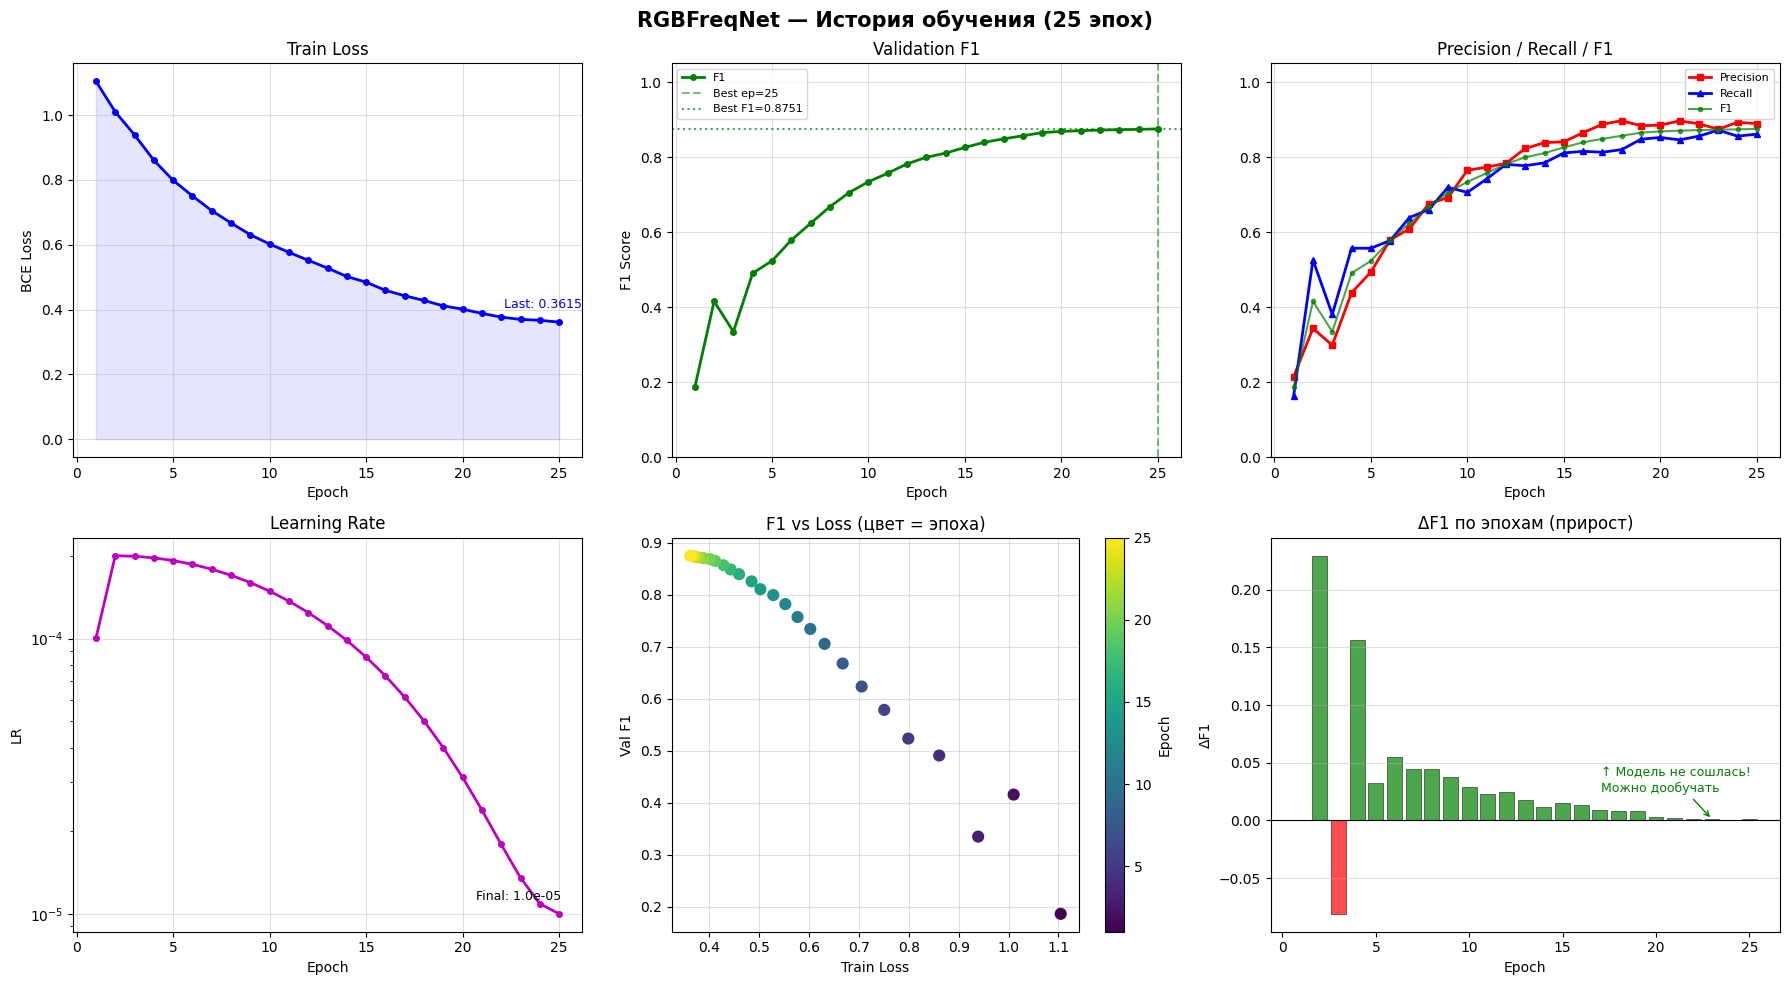

График сохранён.

=== Статистика обучения ===
Loss: 1.1047 → 0.3615  (снизился в 3.1×)
F1:   0.1861 → 0.8751  (лучшая на эпохе 25)
LR:   1.00e-04 → 1.00e-05
Последние 5 эпох ΔF1: ['0.0020', '0.0016', '0.0010', '0.0008', '0.0012']

Вывод: loss всё ещё падает (0.3615), модель НЕ сошлась.
Дообучение с lr=5.0e-05 ожидаемо даст +0.01–0.02 F1


In [ ]:
epochs_h = [h['epoch'] for h in history]
losses   = [h['loss'] for h in history]
f1s      = [h['f1']   for h in history]
precs    = [h['p']    for h in history]
recalls  = [h['r']    for h in history]
lrs      = [h['lr']   for h in history]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('RGBFreqNet — История обучения (25 эпох)', fontsize=15, fontweight='bold')

# ── Train Loss
ax = axes[0, 0]
ax.plot(epochs_h, losses, 'b-o', ms=4, lw=2)
ax.fill_between(epochs_h, losses, alpha=0.1, color='blue')
ax.set_title('Train Loss', fontsize=12)
ax.set_xlabel('Epoch'); ax.set_ylabel('BCE Loss')
ax.grid(True, alpha=0.4)
ax.annotate(f'Last: {losses[-1]:.4f}',
            xy=(epochs_h[-1], losses[-1]),
            xytext=(-40, 10), textcoords='offset points',
            fontsize=9, color='blue')

# ── Val F1
ax = axes[0, 1]
ax.plot(epochs_h, f1s, 'g-o', ms=4, lw=2, label='F1')
best_ep = epochs_h[f1s.index(max(f1s))]
best_f1 = max(f1s)
ax.axvline(best_ep, color='green', ls='--', alpha=0.5, label=f'Best ep={best_ep}')
ax.axhline(best_f1, color='green', ls=':', alpha=0.7, label=f'Best F1={best_f1:.4f}')
ax.set_title('Validation F1', fontsize=12)
ax.set_xlabel('Epoch'); ax.set_ylabel('F1 Score')
ax.legend(fontsize=8); ax.grid(True, alpha=0.4)
ax.set_ylim([0, 1.05])

# ── Precision & Recall
ax = axes[0, 2]
ax.plot(epochs_h, precs,   'r-s', ms=4, lw=2, label='Precision')
ax.plot(epochs_h, recalls, 'b-^', ms=4, lw=2, label='Recall')
ax.plot(epochs_h, f1s,     'g-o', ms=3, lw=1.5, label='F1', alpha=0.7)
ax.set_title('Precision / Recall / F1', fontsize=12)
ax.set_xlabel('Epoch')
ax.legend(fontsize=8); ax.grid(True, alpha=0.4)
ax.set_ylim([0, 1.05])

# ── Learning Rate
ax = axes[1, 0]
ax.plot(epochs_h, lrs, 'm-o', ms=4, lw=2)
ax.set_title('Learning Rate', fontsize=12)
ax.set_xlabel('Epoch'); ax.set_ylabel('LR')
ax.set_yscale('log')
ax.grid(True, alpha=0.4)
ax.annotate(f'Final: {lrs[-1]:.1e}', xy=(epochs_h[-1], lrs[-1]),
            xytext=(-60, 10), textcoords='offset points', fontsize=9)

# ── F1 vs Loss scatter
ax = axes[1, 1]
sc = ax.scatter(losses, f1s, c=epochs_h, cmap='viridis', s=60, zorder=3)
plt.colorbar(sc, ax=ax, label='Epoch')
ax.set_title('F1 vs Loss (цвет = эпоха)', fontsize=12)
ax.set_xlabel('Train Loss'); ax.set_ylabel('Val F1')
ax.grid(True, alpha=0.4)

# ── F1 прирост по эпохам (delta)
ax = axes[1, 2]
deltas = [0] + [f1s[i] - f1s[i-1] for i in range(1, len(f1s))]
colors = ['green' if d >= 0 else 'red' for d in deltas]
ax.bar(epochs_h, deltas, color=colors, alpha=0.7, edgecolor='black', lw=0.5)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('ΔF1 по эпохам (прирост)', fontsize=12)
ax.set_xlabel('Epoch'); ax.set_ylabel('ΔF1')
ax.grid(True, alpha=0.4, axis='y')

# Добавляем аннотацию: модель не сошлась
ax.annotate('↑ Модель не сошлась!\nМожно дообучать',
            xy=(epochs_h[-3], deltas[-3]),
            xytext=(-80, 20), textcoords='offset points',
            fontsize=9, color='green',
            arrowprops=dict(arrowstyle='->', color='green'))

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves_original.png', dpi=150, bbox_inches='tight')
plt.show()
print('График сохранён.')

# Вывод статистики
print(f'\n=== Статистика обучения ===')
print(f'Loss: {losses[0]:.4f} → {losses[-1]:.4f}  (снизился в {losses[0]/losses[-1]:.1f}×)')
print(f'F1:   {f1s[0]:.4f} → {best_f1:.4f}  (лучшая на эпохе {best_ep})')
print(f'LR:   {lrs[0]:.2e} → {lrs[-1]:.2e}')
print(f'Последние 5 эпох ΔF1: {[f"{d:.4f}" for d in deltas[-5:]]}')
print(f'\nВывод: loss всё ещё падает ({losses[-1]:.4f}), модель НЕ сошлась.')
print(f'Дообучение с lr={CFG_FT["ft_lr"]:.1e} ожидаемо даст +0.01–0.02 F1')

## 2. Архитектура (дублирование)

In [ ]:
# ── Все блоки архитектуры (идентичны первому обучению)

class SEBlock(nn.Module):
    def __init__(self, ch, r=8):
        super().__init__()
        h=max(ch//r,8)
        self.pool=nn.AdaptiveAvgPool2d(1)
        self.fc=nn.Sequential(
            nn.Conv2d(ch,h,1,bias=True),nn.SiLU(True),
            nn.Conv2d(h,ch,1,bias=True),nn.Sigmoid())
    def forward(self,x): return x*self.fc(self.pool(x))

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, use_se=True):
        super().__init__()
        self.c1=nn.Sequential(
            nn.Conv2d(in_ch,out_ch,3,stride=stride,padding=1,bias=False),
            nn.BatchNorm2d(out_ch),nn.SiLU(True))
        self.c2=nn.Sequential(
            nn.Conv2d(out_ch,out_ch,3,padding=1,bias=False),
            nn.BatchNorm2d(out_ch))
        self.se=SEBlock(out_ch) if use_se else nn.Identity()
        self.act=nn.SiLU(True)
        self.skip=(
            nn.Sequential(
                nn.Conv2d(in_ch,out_ch,1,stride=stride,bias=False),
                nn.BatchNorm2d(out_ch))
            if (stride!=1 or in_ch!=out_ch) else nn.Identity())
    def forward(self,x):
        return self.act(self.se(self.c2(self.c1(x)))+self.skip(x))

class FixedSRMConv(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv=nn.Conv2d(3,9,5,padding=2,bias=False,groups=3)
        k1=np.array([[0,0,0,0,0],[0,-1,2,-1,0],[0,2,-4,2,0],[0,-1,2,-1,0],[0,0,0,0,0]],np.float32)/4.
        k2=np.array([[-1,2,-2,2,-1],[2,-6,8,-6,2],[-2,8,-12,8,-2],[2,-6,8,-6,2],[-1,2,-2,2,-1]],np.float32)/12.
        k3=np.array([[0,0,0,0,0],[0,0,0,0,0],[0,1,-2,1,0],[0,0,0,0,0],[0,0,0,0,0]],np.float32)/2.
        kk=np.stack([k1,k2,k3],axis=0)
        w=np.zeros((9,1,5,5),np.float32)
        for c in range(3):
            for i in range(3): w[c*3+i,0]=kk[i]
        with torch.no_grad(): self.conv.weight.copy_(torch.from_numpy(w))
        self.conv.weight.requires_grad_(False)
    def forward(self,x): return self.conv(x)

def extract_phase_cos_sin(x: torch.Tensor, hpf_scale: int = 4) -> torch.Tensor:
    xf = torch.fft.fft2(x, norm='ortho')
    xf = torch.fft.fftshift(xf, dim=[-2,-1])
    b, c, h, w = xf.shape
    s = hpf_scale
    mask = torch.ones(1, 1, h, w, dtype=x.dtype, device=x.device)
    mask[:, :, h//2-h//s : h//2+h//s, w//2-w//s : w//2+w//s] = 0.
    xf = xf * mask
    phase = torch.angle(xf)
    return torch.cat([torch.cos(phase), torch.sin(phase)], dim=1)

class RGBFreqNet(nn.Module):
    def __init__(self, rgb_base_ch=64, freq_ch=128, hpf_scale=4, dropout=0.3):
        super().__init__()
        self.hpf_scale = hpf_scale
        B = rgb_base_ch; F = freq_ch

        self.rgb_stem = nn.Sequential(
            nn.Conv2d(3,B,7,stride=2,padding=3,bias=False),
            nn.BatchNorm2d(B),nn.SiLU(True),
            nn.MaxPool2d(3,stride=2,padding=1))
        self.rgb_layer1 = nn.Sequential(ResBlock(B,B*2,stride=2), ResBlock(B*2,B*2))
        self.rgb_layer2 = nn.Sequential(ResBlock(B*2,B*4,stride=2), ResBlock(B*4,B*4))
        self.rgb_layer3 = nn.Sequential(ResBlock(B*4,B*8,stride=2), ResBlock(B*8,B*8))
        self.rgb_pool   = nn.AdaptiveAvgPool2d(1)

        self.srm_conv = FixedSRMConv()
        self.srm_net  = nn.Sequential(
            nn.Conv2d(9,F//2,3,stride=2,padding=1,bias=False),
            nn.BatchNorm2d(F//2),nn.SiLU(True),
            ResBlock(F//2,F,stride=2,use_se=False),
            ResBlock(F,F,stride=2,use_se=False),
            ResBlock(F,F*2,stride=2,use_se=False),
            nn.AdaptiveAvgPool2d(1),nn.Flatten())
        self.srm_proj = nn.Linear(F*2, F)

        self.phase_net = nn.Sequential(
            nn.Conv2d(6,F//2,3,stride=2,padding=1,bias=False),
            nn.BatchNorm2d(F//2),nn.SiLU(True),
            ResBlock(F//2,F,stride=2,use_se=False),
            ResBlock(F,F,stride=2,use_se=False),
            ResBlock(F,F*2,stride=2,use_se=False),
            nn.AdaptiveAvgPool2d(1),nn.Flatten())
        self.phase_proj = nn.Linear(F*2, F)

        fused_dim = B*8 + F + F
        self.head = nn.Sequential(
            nn.BatchNorm1d(fused_dim),nn.Dropout(dropout),
            nn.Linear(fused_dim,256),nn.SiLU(True),
            nn.Dropout(dropout*0.5),nn.Linear(256,1))

        for m in self.modules():
            if isinstance(m,nn.Conv2d) and m.weight.requires_grad:
                nn.init.kaiming_normal_(m.weight,mode='fan_out',nonlinearity='relu')
            elif isinstance(m,(nn.BatchNorm2d,nn.BatchNorm1d)):
                nn.init.constant_(m.weight,1); nn.init.constant_(m.bias,0)
            elif isinstance(m,nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        r = self.rgb_pool(self.rgb_layer3(
            self.rgb_layer2(self.rgb_layer1(self.rgb_stem(x))))).flatten(1)
        with torch.no_grad(): srm_in = self.srm_conv(x)
        s = self.srm_proj(self.srm_net(srm_in))
        p = self.phase_proj(self.phase_net(
            extract_phase_cos_sin(x, self.hpf_scale)))
        return self.head(torch.cat([r, s, p], dim=1))

print('Architecture defined.')

Architecture defined.


## 3. Dataset и трансформы для дообучения

In [ ]:
IMAGE_EXTS = {'.jpg','.jpeg','.png','.bmp','.webp'}

def build_stem_map(d):
    d=Path(d)
    m={p.stem:p for p in d.iterdir()
       if p.suffix.lower() in IMAGE_EXTS and p.is_file()}
    if not m: raise FileNotFoundError(d)
    return m

class FaceDataset(Dataset):
    def __init__(self, df, images_dir, transform, with_target=True):
        self.df=df.reset_index(drop=True); self.tf=transform
        self.with_target=with_target
        self.stem_map=build_stem_map(images_dir)
    def __len__(self): return len(self.df)
    def _read(self, path):
        img=cv2.imread(str(path),cv2.IMREAD_COLOR)
        if img is None: raise FileNotFoundError(path)
        return cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    def __getitem__(self, idx):
        row=self.df.iloc[idx]
        img=self._read(self.stem_map[str(row['Id'])])
        if not self.with_target:
            img=self.tf(image=img)['image']
            return torch.from_numpy(img.transpose(2,0,1).astype(np.float32)),row['Id']
        img=self.tf(image=img)['image']
        return (torch.from_numpy(img.transpose(2,0,1).astype(np.float32)),
                torch.tensor(float(row['target_feature']),dtype=torch.float32))


def build_ft_train_tf(sz):
    return A.Compose([
        A.Resize(sz,sz),
        A.HorizontalFlip(p=CFG_FT['aug_flip_p']),
        A.OneOf([
            A.RandomBrightnessContrast(0.10, 0.10, p=1.),
            A.HueSaturationValue(5, 8, 6, p=1.),
        ], p=CFG_FT['aug_color_p']),
        A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ])

def build_valid_tf(sz):
    return A.Compose([
        A.Resize(sz,sz),
        A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ])

print('Transforms ready.')

Transforms ready.


## 4. Утилиты обучения

In [ ]:
class ModelEMA:
    def __init__(self, model, decay=0.9995):
        self.decay=decay
        self.model=deepcopy(model).eval()
        for p in self.model.parameters(): p.requires_grad_(False)
    @torch.no_grad()
    def update(self, model):
        for k,v in self.model.state_dict().items():
            mv=model.state_dict()[k]
            if v.dtype.is_floating_point:
                v.mul_(self.decay).add_(mv,alpha=1-self.decay)
            else: v.copy_(mv)


def build_cosine_scheduler(optimizer, epochs, steps_per_epoch,
                            warmup_epochs=0.5, min_lr_ratio=0.1):
    total  = max(epochs*steps_per_epoch,1)
    warmup = int(warmup_epochs*steps_per_epoch)
    def fn(step):
        if warmup>0 and step<warmup: return (step+1)/max(warmup,1)
        p=(step-warmup)/max(total-warmup,1)
        cos=0.5*(1+math.cos(math.pi*min(max(p,0.),1.)))
        return min_lr_ratio+(1-min_lr_ratio)*cos
    return LambdaLR(optimizer, fn)


def find_best_threshold(probs, y_true, n=401):
    best={'thr':0.5,'f1':-1.,'p':0.,'r':0.}
    for thr in np.linspace(0.05,0.95,n):
        pred=(probs>=thr).astype(int)
        f1=f1_score(y_true,pred,zero_division=0)
        if f1>best['f1']:
            best={'thr':float(thr),'f1':float(f1),
                  'p':float(precision_score(y_true,pred,zero_division=0)),
                  'r':float(recall_score(y_true,pred,zero_division=0))}
    return best


@torch.no_grad()
def collect_logits(model, loader, device):
    model.eval()
    lg, tg = [], []
    for imgs, targets in loader:
        lg.append(model(imgs.to(device,non_blocking=True)).squeeze(1).cpu().numpy())
        tg.append(targets.numpy())
    return np.concatenate(lg), np.concatenate(tg).astype(int)


def train_one_epoch_ft(model, loader, optimizer, scheduler, scaler,
                       device, ema, pos_weight, label_smoothing):
    model.train()
    total_loss = 0.
    pbar = tqdm(loader, desc='  FT', leave=False)
    for imgs, tgts in pbar:
        imgs = imgs.to(device, non_blocking=True)
        tgts = tgts.to(device, non_blocking=True)
        if label_smoothing > 0:
            tgts = tgts*(1-label_smoothing) + 0.5*label_smoothing
        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=CFG_ORIG['amp'] and device.type=='cuda'):
            logits = model(imgs).squeeze(1)
            loss   = F.binary_cross_entropy_with_logits(
                logits, tgts, pos_weight=pos_weight)
        scaler.scale(loss).backward()
        if CFG_FT['ft_grad_clip'] > 0:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), CFG_FT['ft_grad_clip'])
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        ema.update(model)
        total_loss += loss.item()*imgs.size(0)
        pbar.set_postfix(loss=f'{loss.item():.4f}')
    return total_loss / len(loader.dataset)


print('Utilities ready.')

Utilities ready.


## 5. Загрузка чекпоинта и дообучение

In [ ]:
# ── Загружаем чекпоинт из Drive
ckpt_path_drive = os.path.join(DRIVE_DIR, 'rgbfreq_best.pt')
ckpt = torch.load(ckpt_path_drive, map_location=DEVICE)
print(f'Загружен чекпоинт: epoch={ckpt["epoch"]}  best_f1={ckpt["best_f1"]:.4f}')

model = RGBFreqNet(
    rgb_base_ch = CFG_ORIG['rgb_base_ch'],
    freq_ch     = CFG_ORIG['freq_ch'],
    hpf_scale   = CFG_ORIG['hpf_scale'],
    dropout     = CFG_ORIG['dropout'],
).to(DEVICE)
model.load_state_dict(ckpt['state_dict'])
print('Веса загружены.')

# EMA инициализируем с теми же весами
ema = ModelEMA(model, CFG_ORIG['ema_decay'])

# ── DataLoaders
set_seed(CFG_ORIG['seed'])

train_ds = FaceDataset(
    train_df, TRAIN_IMG_PATH,
    build_ft_train_tf(CFG_ORIG['image_size']))
val_ds = FaceDataset(
    holdout_df, TRAIN_IMG_PATH,
    build_valid_tf(CFG_ORIG['image_size']))

train_loader = DataLoader(
    train_ds, batch_size=CFG_ORIG['batch_size'], shuffle=True,
    num_workers=CFG_ORIG['num_workers'], pin_memory=True, drop_last=True)
val_loader = DataLoader(
    val_ds, batch_size=CFG_ORIG['batch_size']*2, shuffle=False,
    num_workers=CFG_ORIG['num_workers'], pin_memory=True)

pw_tensor = torch.tensor([CFG_FT['pos_weight']], device=DEVICE, dtype=torch.float32)

# ── Optimizer: свежий с маленьким lr
optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CFG_FT['ft_lr'], weight_decay=CFG_FT['ft_weight_decay'])
scheduler = build_cosine_scheduler(
    optimizer, CFG_FT['ft_epochs'], len(train_loader),
    CFG_FT['ft_warmup_epochs'], CFG_FT['ft_min_lr_ratio'])
scaler = GradScaler(enabled=CFG_ORIG['amp'] and DEVICE.type=='cuda')

# ── Базовая валидация перед дообучением
print('\nВалидация до дообучения...')
base_logits, base_y = collect_logits(model, val_loader, DEVICE)
base_probs = 1./(1.+np.exp(-base_logits))
base_m = find_best_threshold(base_probs, base_y)
print(f'Baseline: F1={base_m["f1"]:.4f}  P={base_m["p"]:.4f}  R={base_m["r"]:.4f}  thr={base_m["thr"]:.4f}')

best_f1   = base_m['f1']   # стартуем с текущего лучшего
best_thr  = base_m['thr']
no_improve = 0
ft_history = []
ft_ckpt_path = OUTPUT_DIR / 'rgbfreq_ft_best.pt'

print(f'\n{"="*68}')
print(f'Fine-tuning: {CFG_FT["ft_epochs"]} эпох | '
      f'LR: {CFG_FT["ft_lr"]:.1e} → {CFG_FT["ft_lr"]*CFG_FT["ft_min_lr_ratio"]:.1e}')
print(f'Baseline F1: {best_f1:.4f} | Ожидаем: +0.01–0.02')
print(f'{"="*68}')

for epoch in range(1, CFG_FT['ft_epochs'] + 1):
    train_loss = train_one_epoch_ft(
        model, train_loader, optimizer, scheduler, scaler,
        DEVICE, ema, pw_tensor, CFG_FT['ft_label_smoothing'])

    logits_v, y_v = collect_logits(ema.model, val_loader, DEVICE)
    probs_v = 1./(1.+np.exp(-logits_v))
    m = find_best_threshold(probs_v, y_v)

    lr_now = optimizer.param_groups[0]['lr']
    ft_history.append({'epoch':epoch,'loss':float(train_loss),**m,'lr':float(lr_now)})

    sign = '✓' if m['f1'] > best_f1 else ' '
    print(f'FT{epoch:02d} {sign} | loss={train_loss:.4f} | '
          f'f1={m["f1"]:.4f} (+{m["f1"]-base_m["f1"]:+.4f}) | '
          f'p={m["p"]:.4f} | r={m["r"]:.4f} | '
          f'thr={m["thr"]:.3f} | lr={lr_now:.2e}')

    if m['f1'] > best_f1:
        best_f1=m['f1']; best_thr=m['thr']; no_improve=0
        torch.save({
            'state_dict': ema.model.state_dict(),
            'threshold':  best_thr, 'best_f1': best_f1,
            'ft_epoch':   epoch, 'orig_epoch': ckpt['epoch'],
        }, ft_ckpt_path)
    else:
        no_improve += 1
        if CFG_FT['ft_early_stop']>0 and no_improve>=CFG_FT['ft_early_stop']:
            print(f'Early stopping at FT epoch {epoch}')
            break

print(f'\nFine-tune завершён.')
print(f'Baseline F1: {base_m["f1"]:.4f}')
print(f'Best FT F1:  {best_f1:.4f}  (прирост: {best_f1-base_m["f1"]:+.4f})')

Загружен чекпоинт: epoch=25  best_f1=0.8751
Веса загружены.

Валидация до дообучения...
Baseline: F1=0.8751  P=0.8808  R=0.8694  thr=0.4347

Fine-tuning: 15 эпох | LR: 5.0e-05 → 5.0e-06
Baseline F1: 0.8751 | Ожидаем: +0.01–0.02


FT01 ✓ | loss=0.2912 | f1=0.8799 (++0.0048) | p=0.8963 | r=0.8641 | thr=0.714 | lr=4.99e-05


FT02 ✓ | loss=0.2988 | f1=0.8804 (++0.0054) | p=0.9045 | r=0.8576 | thr=0.774 | lr=4.88e-05


FT03 ✓ | loss=0.2811 | f1=0.8826 (++0.0075) | p=0.9013 | r=0.8647 | thr=0.756 | lr=4.68e-05


FT04 ✓ | loss=0.2683 | f1=0.8880 (++0.0130) | p=0.8968 | r=0.8794 | thr=0.635 | lr=4.38e-05


...

FT08   | loss=0.2329 | f1=0.8910 (++0.0159) | p=0.9130 | r=0.8700 | thr=0.833 | lr=2.63e-05


FT09   | loss=0.2281 | f1=0.8923 (++0.0172) | p=0.9080 | r=0.8771 | thr=0.754 | lr=2.15e-05


FT10   | loss=0.2216 | f1=0.8919 (++0.0169) | p=0.9055 | r=0.8788 | thr=0.707 | lr=1.70e-05


FT11   | loss=0.2168 | f1=0.8912 (++0.0161) | p=0.8912 | r=0.8912 | thr=0.419 | lr=1.29e-05


FT12   | loss=0.2132 | f1=0.8909 (++0.0158) | p=0.9008 | r=0.8812 | thr=0.570 | lr=9.59e-06
Early stopping at FT epoch 12

Fine-tune завершён.
Baseline F1: 0.8751
Best FT F1:  0.8927  (прирост: +0.0176)


## 6. График дообучения

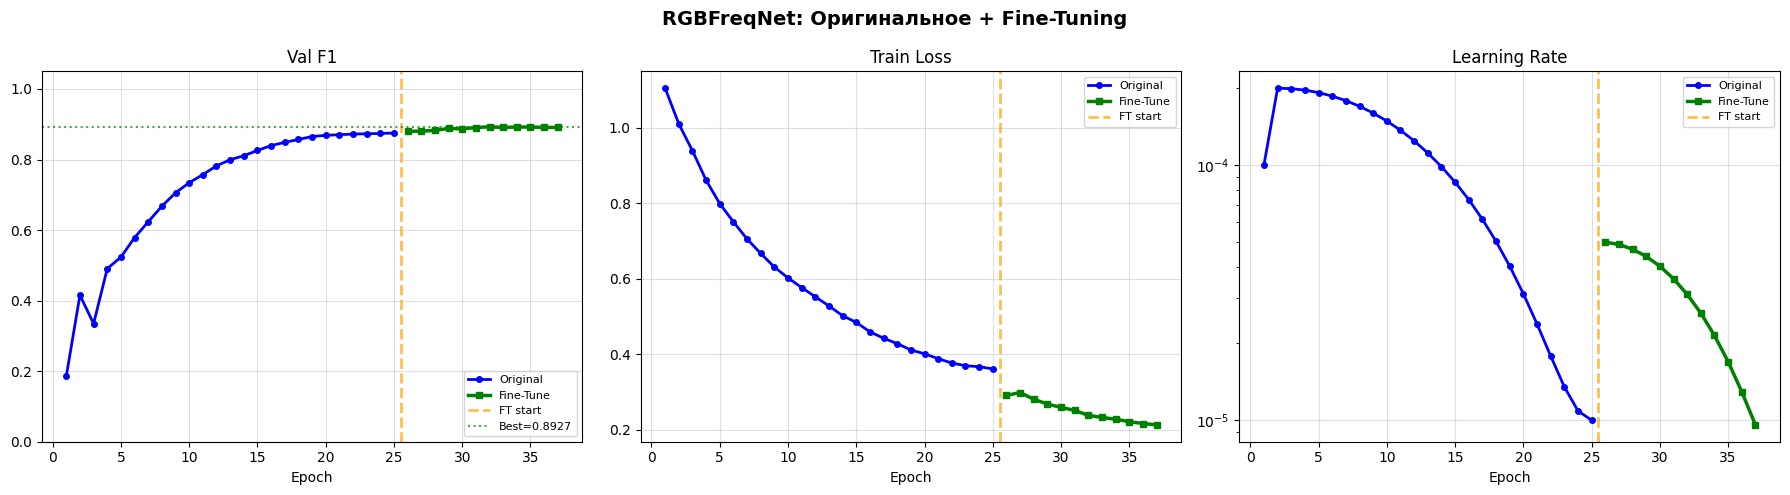

График сохранён.


In [ ]:
# Объединяем историю оригинального и fine-tune обучения
# Для ft_history смещаем эпохи
orig_epochs = len(history)
ft_epochs_list   = [orig_epochs + h['epoch'] for h in ft_history]

all_epochs = epochs_h + ft_epochs_list
all_f1s    = f1s + [h['f1'] for h in ft_history]
all_losses = losses + [h['loss'] for h in ft_history]
all_lrs    = lrs + [h['lr'] for h in ft_history]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('RGBFreqNet: Оригинальное + Fine-Tuning', fontsize=14, fontweight='bold')

# Разделительная линия между orig и ft
def add_ft_separator(ax):
    ax.axvline(orig_epochs + 0.5, color='orange', ls='--', lw=2, alpha=0.7, label='FT start')

# F1
ax = axes[0]
ax.plot(epochs_h,     f1s,                        'b-o', ms=4, lw=2, label='Original')
ax.plot(ft_epochs_list, [h['f1'] for h in ft_history], 'g-s', ms=5, lw=2.5, label='Fine-Tune')
add_ft_separator(ax)
ax.axhline(best_f1, color='green', ls=':', alpha=0.7, label=f'Best={best_f1:.4f}')
ax.set_title('Val F1'); ax.set_xlabel('Epoch'); ax.legend(fontsize=8)
ax.grid(True, alpha=0.4); ax.set_ylim([0, 1.05])

# Loss
ax = axes[1]
ax.plot(epochs_h,     losses,                        'b-o', ms=4, lw=2, label='Original')
ax.plot(ft_epochs_list, [h['loss'] for h in ft_history], 'g-s', ms=5, lw=2.5, label='Fine-Tune')
add_ft_separator(ax)
ax.set_title('Train Loss'); ax.set_xlabel('Epoch'); ax.legend(fontsize=8)
ax.grid(True, alpha=0.4)

# LR
ax = axes[2]
ax.plot(epochs_h,     lrs,                        'b-o', ms=4, lw=2, label='Original')
ax.plot(ft_epochs_list, [h['lr'] for h in ft_history], 'g-s', ms=5, lw=2.5, label='Fine-Tune')
add_ft_separator(ax)
ax.set_title('Learning Rate'); ax.set_xlabel('Epoch')
ax.set_yscale('log'); ax.legend(fontsize=8); ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves_combined.png', dpi=150, bbox_inches='tight')
plt.show()
print('График сохранён.')

## 7. Инференс с TTA

In [ ]:
# Загружаем лучший FT чекпоинт
ft_ckpt = torch.load(ft_ckpt_path, map_location=DEVICE)
model_eval = RGBFreqNet(
    CFG_ORIG['rgb_base_ch'], CFG_ORIG['freq_ch'],
    CFG_ORIG['hpf_scale'], CFG_ORIG['dropout']).to(DEVICE)
model_eval.load_state_dict(ft_ckpt['state_dict'])
model_eval.eval()
print(f'FT checkpoint: orig_epoch={ft_ckpt["orig_epoch"]}+{ft_ckpt["ft_epoch"]} '
      f'FT  | best_f1={ft_ckpt["best_f1"]:.4f}')


@torch.no_grad()
def predict_tta_extended(model, loader, device):
    """TTA: orig + hflip."""
    model.eval()
    logits_list = {v: [] for v in CFG_FT['tta_variants']}
    targets_all, ids_all = [], []

    for batch in tqdm(loader, leave=False, desc='Predict TTA'):
        imgs  = batch[0].to(device, non_blocking=True)
        extra = batch[1]

        if 'orig' in CFG_FT['tta_variants']:
            logits_list['orig'].append(
                model(imgs).squeeze(1).cpu().numpy())
        if 'hflip' in CFG_FT['tta_variants']:
            logits_list['hflip'].append(
                model(torch.flip(imgs, dims=[3])).squeeze(1).cpu().numpy())
        if 'rot90' in CFG_FT['tta_variants']:
            logits_list['rot90'].append(
                model(torch.rot90(imgs, k=1, dims=[2,3])).squeeze(1).cpu().numpy())

        if torch.is_tensor(extra): targets_all.append(extra.numpy())
        else: ids_all.extend([str(x) for x in extra])

    # Усредняем логиты (равномерно)
    all_logits = np.stack([
        np.concatenate(logits_list[v])
        for v in CFG_FT['tta_variants']
    ], axis=0).mean(axis=0)
    probs = 1./(1.+np.exp(-all_logits))

    if targets_all:
        return all_logits, probs, np.concatenate(targets_all).astype(int)
    return all_logits, probs, ids_all


# ── Holdout с TTA
print('Holdout inference...')
h_lg, h_pr, h_y = predict_tta_extended(model_eval, val_loader, DEVICE)
mh = find_best_threshold(h_pr, h_y)
print(f'[Holdout TTA×{len(CFG_FT["tta_variants"])}] '
      f'F1={mh["f1"]:.4f}  P={mh["p"]:.4f}  R={mh["r"]:.4f}  thr={mh["thr"]:.4f}')

# Сравниваем с baseline
print(f'\nИтоговое сравнение:')
print(f'  Исходная модель (ep25):       F1={ckpt["best_f1"]:.4f}')
print(f'  После fine-tune:              F1={mh["f1"]:.4f}  ({mh["f1"]-ckpt["best_f1"]:+.4f})')
print(f'  Прирост от расширенного TTA:  сравним с hflip-only для оценки')

np.save(OUTPUT_DIR / 'rgbfreq_ft_holdout_probs.npy',  h_pr)
np.save(OUTPUT_DIR / 'rgbfreq_ft_holdout_logits.npy', h_lg)
np.save(OUTPUT_DIR / 'rgbfreq_ft_holdout_y_true.npy', h_y)
holdout_df.assign(prob=h_pr).to_csv(
    OUTPUT_DIR / 'rgbfreq_ft_holdout_predictions.csv', index=False)
with open(OUTPUT_DIR / 'threshold.json', 'w') as f:
    json.dump({'threshold':mh['thr'],'f1':mh['f1']}, f, indent=2)

FT checkpoint: orig_epoch=25+7 FT  | best_f1=0.8927
Holdout inference...


[Holdout TTA×2] F1=0.8932  P=0.9007  R=0.8859  thr=0.6192

Итоговое сравнение:
  Исходная модель (ep25):       F1=0.8751
  После fine-tune:              F1=0.8932  (+0.0182)
  Прирост от расширенного TTA:  сравним с hflip-only для оценки


In [ ]:
# ── Тест
def load_test_df(d):
    m=build_stem_map(d)
    ids=sorted(m.keys(),key=lambda s:int(s) if s.isdigit() else s)
    return pd.DataFrame({'Id':ids,'target_feature':0})

test_df=load_test_df(TEST_IMG_PATH)
test_ds=FaceDataset(test_df,TEST_IMG_PATH,build_valid_tf(CFG_ORIG['image_size']),with_target=False)
test_loader=DataLoader(test_ds,batch_size=CFG_ORIG['batch_size']*2,shuffle=False,
                       num_workers=CFG_ORIG['num_workers'],pin_memory=True)

print('Test inference...')
t_lg, t_pr, t_ids = predict_tta_extended(model_eval, test_loader, DEVICE)
np.save(OUTPUT_DIR/'rgbfreq_ft_test_probs.npy',  t_pr)
np.save(OUTPUT_DIR/'rgbfreq_ft_test_logits.npy', t_lg)

preds=(t_pr>=mh['thr']).astype(int)
sub=pd.DataFrame({'Id':t_ids,'target_feature':preds})
sub=sub.sort_values('Id',key=lambda c:c.map(lambda s:int(s) if str(s).isdigit() else s))
sub.to_csv(OUTPUT_DIR/'submission_rgbfreq_ft.csv',index=False)
print(f'Submission: {(preds==1).sum()} fake / {(preds==0).sum()} real')

Test inference...


Submission: 1644 fake / 8356 real


In [ ]:
# ── Сохраняем всё в Drive
import shutil
ft_drive_dir = os.path.join(DRIVE_DIR, 'finetune')
os.makedirs(ft_drive_dir, exist_ok=True)

for fname in [
    'rgbfreq_ft_best.pt',
    'rgbfreq_ft_holdout_probs.npy',
    'rgbfreq_ft_holdout_logits.npy',
    'rgbfreq_ft_holdout_y_true.npy',
    'rgbfreq_ft_test_probs.npy',
    'rgbfreq_ft_test_logits.npy',
    'rgbfreq_ft_holdout_predictions.csv',
    'submission_rgbfreq_ft.csv',
    'threshold.json',
    'training_curves_original.png',
    'training_curves_combined.png',
]:
    src = OUTPUT_DIR / fname
    if src.exists():
        shutil.copy(src, os.path.join(ft_drive_dir, fname))
        print(f'  ✓ {fname}')

print(f'\n=== Итог ===')
print(f'Исходная модель:  F1={ckpt["best_f1"]:.4f}  (тест 0.92075)')
print(f'После fine-tune:  F1={mh["f1"]:.4f}  (holdout)')
print(f'Порог:            {mh["thr"]:.4f}')
print(f'\nФайлы для ансамбля:')
print(f'  rgbfreq_ft_holdout_probs.npy  → ensemble optimizer')
print(f'  rgbfreq_ft_test_probs.npy     → submission')

  ✓ rgbfreq_ft_best.pt
  ✓ rgbfreq_ft_holdout_probs.npy
  ✓ rgbfreq_ft_holdout_logits.npy
  ✓ rgbfreq_ft_holdout_y_true.npy
  ✓ rgbfreq_ft_test_probs.npy
  ✓ rgbfreq_ft_test_logits.npy
  ✓ rgbfreq_ft_holdout_predictions.csv
  ✓ submission_rgbfreq_ft.csv
  ✓ threshold.json
  ✓ training_curves_original.png
  ✓ training_curves_combined.png

=== Итог ===
Исходная модель:  F1=0.8751  (тест 0.92075)
После fine-tune:  F1=0.8932  (holdout)
Порог:            0.6192

Файлы для ансамбля:
  rgbfreq_ft_holdout_probs.npy  → ensemble optimizer
  rgbfreq_ft_test_probs.npy     → submission


# Генерация .parquet файлов

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import cv2
import json
import albumentations as A
from pathlib import Path
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# ==========================================
# 1. АРХИТЕКТУРА
# ==========================================

class SEBlock(nn.Module):
    def __init__(self, ch, r=8):
        super().__init__()
        h = max(ch // r, 8)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(ch, h, 1, bias=True), nn.SiLU(True),
            nn.Conv2d(h, ch, 1, bias=True), nn.Sigmoid())
    def forward(self, x): return x * self.fc(self.pool(x))

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1, use_se=True):
        super().__init__()
        self.c1 = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.SiLU(True))
        self.c2 = nn.Sequential(
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch))
        self.se = SEBlock(out_ch) if use_se else nn.Identity()
        self.act = nn.SiLU(True)
        self.skip = (
            nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch))
            if (stride != 1 or in_ch != out_ch) else nn.Identity())
    def forward(self, x):
        return self.act(self.se(self.c2(self.c1(x))) + self.skip(x))

class FixedSRMConv(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(3, 9, 5, padding=2, bias=False, groups=3)
        k1 = np.array([[0,0,0,0,0],[0,-1,2,-1,0],[0,2,-4,2,0],[0,-1,2,-1,0],[0,0,0,0,0]], np.float32)/4.
        k2 = np.array([[-1,2,-2,2,-1],[2,-6,8,-6,2],[-2,8,-12,8,-2],[2,-6,8,-6,2],[-1,2,-2,2,-1]], np.float32)/12.
        k3 = np.array([[0,0,0,0,0],[0,0,0,0,0],[0,1,-2,1,0],[0,0,0,0,0],[0,0,0,0,0]], np.float32)/2.
        kk = np.stack([k1, k2, k3], axis=0)
        w = np.zeros((9, 1, 5, 5), np.float32)
        for c in range(3):
            for i in range(3): w[c*3+i, 0] = kk[i]
        with torch.no_grad(): self.conv.weight.copy_(torch.from_numpy(w))
        self.conv.weight.requires_grad_(False)
    def forward(self, x): return self.conv(x)

def extract_phase_cos_sin(x: torch.Tensor, hpf_scale: int = 4) -> torch.Tensor:
    xf = torch.fft.fft2(x, norm='ortho')
    xf = torch.fft.fftshift(xf, dim=[-2, -1])
    b, c, h, w = xf.shape
    s = hpf_scale
    mask = torch.ones(1, 1, h, w, dtype=x.dtype, device=x.device)
    mask[:, :, h//2-h//s : h//2+h//s, w//2-w//s : w//2+w//s] = 0.
    xf = xf * mask
    phase = torch.angle(xf)
    return torch.cat([torch.cos(phase), torch.sin(phase)], dim=1)

class RGBFreqNet(nn.Module):
    def __init__(self, rgb_base_ch=64, freq_ch=128, hpf_scale=4, dropout=0.3):
        super().__init__()
        self.hpf_scale = hpf_scale
        B = rgb_base_ch; F = freq_ch
        self.rgb_stem = nn.Sequential(
            nn.Conv2d(3, B, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(B), nn.SiLU(True),
            nn.MaxPool2d(3, stride=2, padding=1))
        self.rgb_layer1 = nn.Sequential(ResBlock(B, B*2, stride=2), ResBlock(B*2, B*2))
        self.rgb_layer2 = nn.Sequential(ResBlock(B*2, B*4, stride=2), ResBlock(B*4, B*4))
        self.rgb_layer3 = nn.Sequential(ResBlock(B*4, B*8, stride=2), ResBlock(B*8, B*8))
        self.rgb_pool   = nn.AdaptiveAvgPool2d(1)
        self.srm_conv = FixedSRMConv()
        self.srm_net  = nn.Sequential(
            nn.Conv2d(9, F//2, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(F//2), nn.SiLU(True),
            ResBlock(F//2, F, stride=2, use_se=False),
            ResBlock(F, F, stride=2, use_se=False),
            ResBlock(F, F*2, stride=2, use_se=False),
            nn.AdaptiveAvgPool2d(1), nn.Flatten())
        self.srm_proj = nn.Linear(F*2, F)
        self.phase_net = nn.Sequential(
            nn.Conv2d(6, F//2, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(F//2), nn.SiLU(True),
            ResBlock(F//2, F, stride=2, use_se=False),
            ResBlock(F, F, stride=2, use_se=False),
            ResBlock(F, F*2, stride=2, use_se=False),
            nn.AdaptiveAvgPool2d(1), nn.Flatten())
        self.phase_proj = nn.Linear(F*2, F)
        fused_dim = B*8 + F + F
        self.head = nn.Sequential(
            nn.BatchNorm1d(fused_dim), nn.Dropout(dropout),
            nn.Linear(fused_dim, 256), nn.SiLU(True),
            nn.Dropout(dropout*0.5), nn.Linear(256, 1))

    def forward(self, x):
        r = self.rgb_pool(self.rgb_layer3(
            self.rgb_layer2(self.rgb_layer1(self.rgb_stem(x))))).flatten(1)
        with torch.no_grad(): srm_in = self.srm_conv(x)
        s = self.srm_proj(self.srm_net(srm_in))
        p = self.phase_proj(self.phase_net(extract_phase_cos_sin(x, self.hpf_scale)))
        return self.head(torch.cat([r, s, p], dim=1))

# ==========================================
# 2. ДАТАСЕТ И ПАРАМЕТРЫ
# ==========================================

MODEL_NAME = 'RGBFreqNet'
WEIGHTS_PATH = '/content/drive/MyDrive/ALL_MODELS/weights/RGBFreqNet/rgbfreq_ft_best.pt'
DRIVE_SAVE_PATH = f'/content/drive/MyDrive/ALL_MODELS/{MODEL_NAME}'
BASE_PATH = '/content/dataset_root/dataset'
TRAIN_IMG_PATH = os.path.join(BASE_PATH, 'train_images')
TEST_IMG_PATH = os.path.join(BASE_PATH, 'test_images')
SOLUTION_PATH = os.path.join(BASE_PATH, 'train_solution.csv')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Параметры из CFG_ORIG файла rgbfreq.py
CFG = {'image_size': 256, 'batch_size': 32, 'rgb_base_ch': 64, 'freq_ch': 128, 'hpf_scale': 4, 'dropout': 0.3}

def build_stem_map(d):
    d = Path(d)
    return {p.stem: p for p in d.iterdir() if p.suffix.lower() in {'.jpg','.jpeg','.png'} and p.is_file()}

class FaceDataset(Dataset):
    def __init__(self, df, images_dir, transform, with_target=True):
        self.df = df.reset_index(drop=True); self.tf = transform
        self.with_target = with_target
        self.stem_map = build_stem_map(images_dir)
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(str(self.stem_map[str(row['Id'])]))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = self.tf(image=img)['image']
        img_tensor = torch.from_numpy(img.transpose(2,0,1).astype(np.float32))
        if not self.with_target: return img_tensor, str(row['Id'])
        return img_tensor, torch.tensor(float(row['target_feature']), dtype=torch.float32)

def get_valid_tf(sz):
    return A.Compose([A.Resize(sz, sz), A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])])

# ==========================================
# 3. ЗАГРУЗКА И ИНФЕРЕНС
# ==========================================

print(f"Loading weights from {WEIGHTS_PATH}...")
model = RGBFreqNet(CFG['rgb_base_ch'], CFG['freq_ch'], CFG['hpf_scale'], CFG['dropout']).to(DEVICE)

# ИСПРАВЛЕНИЕ: Загружаем через ключ 'state_dict'
checkpoint = torch.load(WEIGHTS_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['state_dict'])
model.eval()

@torch.no_grad()
def run_tta_inference(loader, is_test=False):
    res_logits, res_ids, res_labels = [], [], []
    for batch in tqdm(loader, desc="Predicting"):
        imgs = batch[0].to(DEVICE)
        # TTA: Orig + HFlip (как в твоем коде)
        l_orig = model(imgs).squeeze(1)
        l_flip = model(torch.flip(imgs, dims=[3])).squeeze(1)
        avg_logits = 0.5 * (l_orig + l_flip)

        res_logits.extend(avg_logits.cpu().numpy())
        if is_test: res_ids.extend(batch[1])
        else: res_labels.extend(batch[1].numpy())

    logits = np.array(res_logits)
    probs = 1 / (1 + np.exp(-logits))
    return logits, probs, (res_ids if is_test else res_labels)

# Подготовка данных
full_df = pd.read_csv(SOLUTION_PATH, header=None, names=['Id', 'target_feature'])
full_df['Id'] = full_df['Id'].astype(str)
_, val_df = train_test_split(full_df, test_size=0.2, random_state=42, stratify=full_df['target_feature'])

def maybe_int(s): return int(s) if str(s).isdigit() else s
test_ids = sorted([p.stem for p in Path(TEST_IMG_PATH).iterdir() if p.is_file()], key=maybe_int)
test_df = pd.DataFrame({'Id': test_ids})

# Выполнение
tf = get_valid_tf(CFG['image_size'])

print("\n--- Validation ---")
val_loader = DataLoader(FaceDataset(val_df, TRAIN_IMG_PATH, tf), batch_size=CFG['batch_size']*2, shuffle=False)
v_lg, v_pr, v_true = run_tta_inference(val_loader)
val_res = pd.DataFrame({'id': val_df['Id'], 'logit': v_lg, 'prob': v_pr, 'true_label': v_true})

print("\n--- Test ---")
test_loader = DataLoader(FaceDataset(test_df, TEST_IMG_PATH, tf, with_target=False), batch_size=CFG['batch_size']*2, shuffle=False)
t_lg, t_pr, t_ids = run_tta_inference(test_loader, is_test=True)
test_res = pd.DataFrame({'id': t_ids, 'logit': t_lg, 'prob': t_pr})

# Сортировка и сохранение
for df, name in [(val_res, 'val'), (test_res, 'test')]:
    df['id_n'] = df['id'].apply(maybe_int)
    df = df.sort_values('id_n').drop(columns=['id_n']).reset_index(drop=True)
    fname = f"{MODEL_NAME}_{name}_preds.parquet"
    df.to_parquet(fname)
    Path(DRIVE_SAVE_PATH).mkdir(parents=True, exist_ok=True)
    !cp {fname} {DRIVE_SAVE_PATH}/

print(f"\nDone! Results saved in {DRIVE_SAVE_PATH}")

Loading weights from /content/drive/MyDrive/ALL_MODELS/weights/RGBFreqNet/rgbfreq_ft_best.pt...

--- Validation ---


Predicting: 100%|██████████| 157/157 [01:28<00:00,  1.77it/s]



--- Test ---


Predicting: 100%|██████████| 157/157 [01:25<00:00,  1.83it/s]



Done! Results saved in /content/drive/MyDrive/ALL_MODELS/RGBFreqNet
